# Cross-modal EEG <-> Voice (VOICE-EEG, SEX-VOICE, FINGER, STAB, EEG-FING)


Voice embeddings: 51 sujetos × 192 dims
Sujetos en común EEG ∩ Voz: 49

PARTE A: Mantel test — similitud EEG ↔ similitud Voz

  Mantel rho  = +0.024
  p (Spearman) = 0.4202
  p (perm 1000) = 0.4220
  → No significativo: EEG y voz no comparten estructura de similitud global.

PARTE B: PCA voz → correlación con features EEG

  Varianza explicada por 10 PCs: 48.3%
  Por PC: PC1=9.9%  PC2=5.6%  PC3=5.5%  PC4=5.0%  PC5=4.2%  PC6=3.9%  PC7=3.8%  PC8=3.5%  PC9=3.5%  PC10=3.4%

  Calculando correlaciones (147 features × 10 PCs)...

  Top 5 EEG features por voice PC (|rho| > 0.28):

  Voice PC1 (9.9% var):
    P7_beta                       rho=+0.374  p=0.008
    asym_O1_O2_gamma              rho=+0.364  p=0.010
    asym_F7_F8_theta              rho=-0.361  p=0.011
    iaf_F8                        rho=+0.359  p=0.011
    asym_F7_F8_alpha              rho=-0.353  p=0.013
  Voice PC2 (5.6% var):
    asym_F3_F4_delta              rho=-0.410  p=0.003
    F8_theta                      rho=-0.303  p

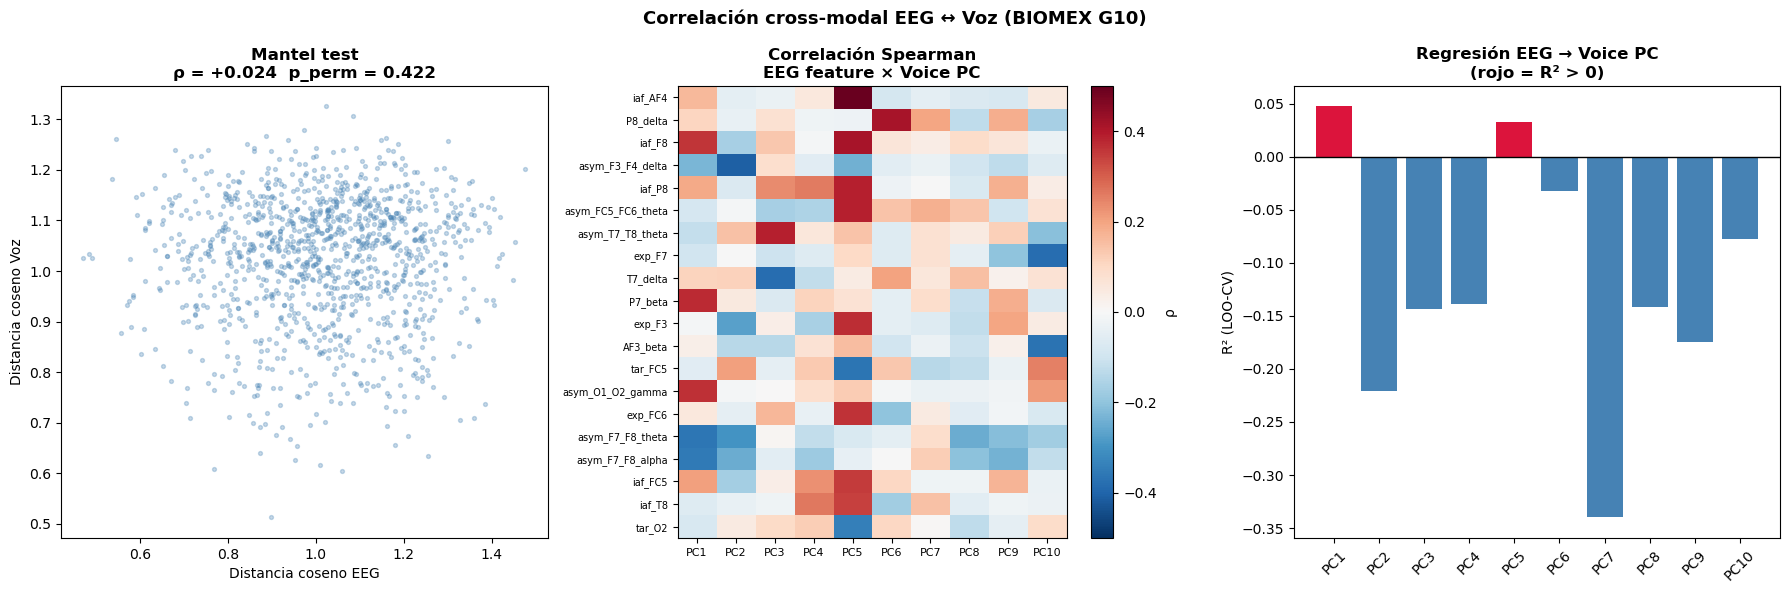

In [18]:
  # ============================================================
  # CELL VOICE-EEG-1: Correlación cross-modal EEG ↔ Voz
  #
  # Parte A: Mantel test — ¿distancias EEG correlacionan con
  #          distancias de voz entre sujetos?
  #
  # Parte B: PCA sobre embeddings de voz → correlación de cada
  #          PC con features EEG (Spearman). Heatmap.
  #
  # Parte C: Regresión EEG → top voice PCs (SVR-RBF, LOO-CV)
  # ============================================================

  import pandas as pd
  import numpy as np
  from scipy.stats import spearmanr
  from scipy.spatial.distance import pdist, squareform
  from sklearn.decomposition import PCA
  from sklearn.preprocessing import StandardScaler
  from sklearn.svm import SVR
  from sklearn.model_selection import LeaveOneOut
  from sklearn.metrics import r2_score
  import warnings
  warnings.filterwarnings('ignore')

  # -- Cargar embeddings de voz (sesión G10, misma que EEG) --------------------
  voice_df = pd.read_csv(
      r'C:\Users\Laura\OneDrive\Escritorio\TFM_part1\voice_embeddings_G10.csv')
  voice_cols = [c for c in voice_df.columns if c.startswith('voice_')]
  print(f"Voice embeddings: {voice_df.shape[0]} sujetos × {len(voice_cols)} dims")

  # -- Alinear sujetos EEG ↔ Voz -----------------------------------------------
  eeg_feat_cols = [c for c in combined.columns
                   if c not in {'subject_id', 'sex', 'age', 'handedness', 'age_group'}]
  merged = combined.merge(voice_df[['subject_id'] + voice_cols],
                          on='subject_id', how='inner')
  print(f"Sujetos en común EEG ∩ Voz: {len(merged)}")

  X_eeg   = merged[eeg_feat_cols].values.astype(float)
  X_voice = merged[voice_cols].values.astype(float)

  # Imputar NaN en EEG
  col_means = np.nanmean(X_eeg, axis=0)
  for i, j in zip(*np.where(np.isnan(X_eeg))):
      X_eeg[i, j] = col_means[j]

  # Estandarizar ambas matrices
  X_eeg_s   = StandardScaler().fit_transform(X_eeg)
  X_voice_s = StandardScaler().fit_transform(X_voice)

  n = len(merged)

  # ============================================================
  # PARTE A — Mantel test
  # ============================================================
  print("\n" + "=" * 56)
  print("PARTE A: Mantel test — similitud EEG ↔ similitud Voz")
  print("=" * 56)

  dist_eeg   = squareform(pdist(X_eeg_s,   metric='cosine'))
  dist_voice = squareform(pdist(X_voice_s, metric='cosine'))

  # Triangular inferior (sin diagonal)
  idx_lower = np.tril_indices(n, k=-1)
  vec_eeg   = dist_eeg[idx_lower]
  vec_voice = dist_voice[idx_lower]

  rho_mantel, p_mantel = spearmanr(vec_eeg, vec_voice)

  # Permutation test para Mantel (1000 perm.)
  rng = np.random.default_rng(42)
  perm_rhos = []
  for _ in range(1000):
      perm_idx = rng.permutation(n)
      dist_perm = dist_eeg[np.ix_(perm_idx, perm_idx)]
      r_p, _ = spearmanr(dist_perm[idx_lower], vec_voice)
      perm_rhos.append(r_p)
  perm_rhos = np.array(perm_rhos)
  p_perm_mantel = (np.abs(perm_rhos) >= np.abs(rho_mantel)).mean()

  print(f"\n  Mantel rho  = {rho_mantel:+.3f}")
  print(f"  p (Spearman) = {p_mantel:.4f}")
  print(f"  p (perm 1000) = {p_perm_mantel:.4f}")
  if p_perm_mantel < 0.05:
      print("  → Significativo: sujetos similares en EEG también suenan parecido.")
  else:
      print("  → No significativo: EEG y voz no comparten estructura de similitud global.")

  # ============================================================
  # PARTE B — PCA voz + correlación con EEG
  # ============================================================
  print("\n" + "=" * 56)
  print("PARTE B: PCA voz → correlación con features EEG")
  print("=" * 56)

  N_PCS = 10
  pca   = PCA(n_components=N_PCS, random_state=42)
  V_pca = pca.fit_transform(X_voice_s)

  var_exp = pca.explained_variance_ratio_
  print(f"\n  Varianza explicada por {N_PCS} PCs: {var_exp.sum()*100:.1f}%")
  print("  Por PC: " + "  ".join([f"PC{i+1}={v*100:.1f}%" for i, v in enumerate(var_exp)]))

  # Spearman de cada EEG feature con cada voice PC
  print(f"\n  Calculando correlaciones ({len(eeg_feat_cols)} features × {N_PCS} PCs)...")
  rho_mat = np.zeros((len(eeg_feat_cols), N_PCS))
  p_mat   = np.zeros((len(eeg_feat_cols), N_PCS))
  for j in range(N_PCS):
      for i, col in enumerate(eeg_feat_cols):
          r, p = spearmanr(X_eeg_s[:, i], V_pca[:, j])
          rho_mat[i, j] = r
          p_mat[i, j]   = p

  # Top features por PC (por |rho|)
  print("\n  Top 5 EEG features por voice PC (|rho| > 0.28):\n")
  for j in range(N_PCS):
      top_idx = np.argsort(np.abs(rho_mat[:, j]))[::-1][:5]
      top_feats = [(eeg_feat_cols[i], rho_mat[i, j], p_mat[i, j]) for i in top_idx
                   if abs(rho_mat[i, j]) > 0.28]
      if top_feats:
          print(f"  Voice PC{j+1} ({var_exp[j]*100:.1f}% var):")
          for fname, rho, p in top_feats:
              print(f"    {fname:<28}  rho={rho:+.3f}  p={p:.3f}")

  # ============================================================
  # PARTE C — Regresión EEG → voice PCs (LOO-CV)
  # ============================================================
  print("\n" + "=" * 56)
  print("PARTE C: Regresión EEG → Voice PCs (SVR-RBF, LOO-CV)")
  print("=" * 56)

  loo = LeaveOneOut()
  print(f"\n  {'PC':<6}  {'var%':>6}  {'R²':>8}  {'r (Pearson)':>13}")
  print("  " + "-" * 38)

  pc_results = {}
  for j in range(N_PCS):
      y_pc  = V_pca[:, j]
      preds = np.zeros(n)
      for tr, te in loo.split(X_eeg_s):
          svr = SVR(kernel='rbf', C=5, epsilon=0.5)
          svr.fit(X_eeg_s[tr], y_pc[tr])
          preds[te] = svr.predict(X_eeg_s[te])
      r2  = r2_score(y_pc, preds)
      r_p = np.corrcoef(y_pc, preds)[0, 1]
      flag = '  *' if r2 > 0 else ''
      pc_results[j] = {'r2': r2, 'r': r_p, 'preds': preds, 'true': y_pc}
      print(f"  PC{j+1:<4}  {var_exp[j]*100:>5.1f}%  {r2:>8.3f}  {r_p:>13.3f}{flag}")

  # -- Plots -------------------------------------------------------------------
  fig, axes = plt.subplots(1, 3, figsize=(18, 6))

  # A: Mantel scatter
  ax = axes[0]
  sample = rng.choice(len(vec_eeg), size=min(2000, len(vec_eeg)), replace=False)
  ax.scatter(vec_eeg[sample], vec_voice[sample],
             alpha=0.3, s=8, color='steelblue')
  ax.set_xlabel('Distancia coseno EEG')
  ax.set_ylabel('Distancia coseno Voz')
  ax.set_title(f'Mantel test\nρ = {rho_mantel:+.3f}  p_perm = {p_perm_mantel:.3f}',
               fontweight='bold')

  # B: Heatmap |rho| EEG feature × Voice PC (top 20 features)
  ax2 = axes[1]
  top_feats_global = np.argsort(np.abs(rho_mat).max(axis=1))[::-1][:20]
  heatmap_data = rho_mat[top_feats_global, :]
  feat_labels  = [eeg_feat_cols[i] for i in top_feats_global]
  im = ax2.imshow(heatmap_data, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
  ax2.set_xticks(range(N_PCS))
  ax2.set_xticklabels([f'PC{j+1}' for j in range(N_PCS)], fontsize=8)
  ax2.set_yticks(range(20))
  ax2.set_yticklabels(feat_labels, fontsize=7)
  ax2.set_title('Correlación Spearman\nEEG feature × Voice PC', fontweight='bold')
  plt.colorbar(im, ax=ax2, label='ρ')

  # C: R² por PC
  ax3 = axes[2]
  r2s    = [pc_results[j]['r2'] for j in range(N_PCS)]
  colors = ['crimson' if r > 0 else 'steelblue' for r in r2s]
  ax3.bar([f'PC{j+1}' for j in range(N_PCS)], r2s, color=colors)
  ax3.axhline(0, color='k', lw=1)
  ax3.set_ylabel('R² (LOO-CV)')
  ax3.set_title('Regresión EEG → Voice PC\n(rojo = R² > 0)', fontweight='bold')
  ax3.tick_params(axis='x', rotation=45)

  plt.suptitle('Correlación cross-modal EEG ↔ Voz (BIOMEX G10)',
               fontsize=13, fontweight='bold')
  plt.tight_layout()
  plt.show()

## SEX-VOICE-1: ¿El eje de sexo en EEG alinea con el de Voz?

El clasificador de sexo desde EEG (SVC-RBF, LOO-CV) genera una probabilidad
continua P(male) por sujeto — el **EEG sex score**.

La proyección LDA sobre los 192 embeddings de voz genera un eje que maximiza
la separación male/female en el espacio de voz — el **Voice sex score**.

Si ambas puntuaciones correlacionan significativamente, EEG y voz codifican
el sexo de forma consistente, lo que valida la cadena EEG → característica
individual → voz que justifica la Fase 3 del TFM.

**Requiere:** VOICE-EEG-1 ejecutado (`merged`, `X_eeg_s`, `X_voice_s`, `n`)

Calculando EEG sex score (SVC-RBF LOO-CV)...
  Accuracy LOO-CV sexo (EEG): 0.592

  EEG sex score <-> Voice sex score:
  Spearman rho = -0.059   p = 0.6883
  Pearson  r   = -0.112   p = 0.4438
  -> No significativo.


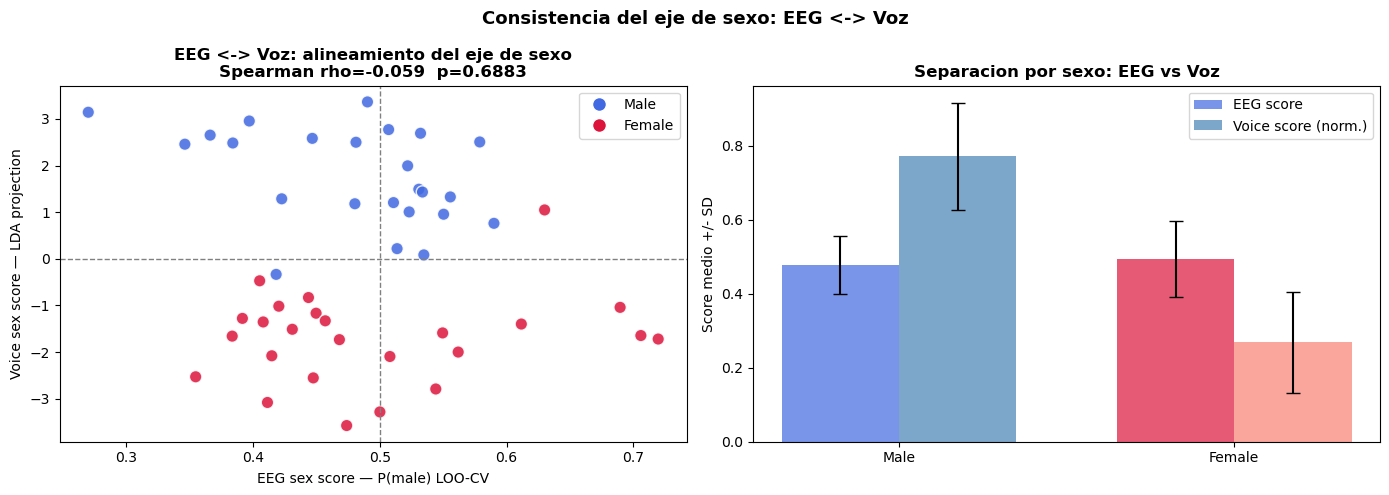

In [41]:
# ============================================================
# CELL SEX-VOICE-1: EEG sex score <-> Voice sex score
# ============================================================

from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut
from scipy.stats import spearmanr, pearsonr
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# str[0] es robusto tanto si sex='M'/'F' como 'Male'/'Female'
y_sex      = (merged['sex'].str[0] == 'M').astype(int).values
sex_labels = merged['sex'].str[0].values   # 'M' o 'F'
loo        = LeaveOneOut()

# -- EEG sex score: P(male) en LOO-CV ----------------------------------------
print("Calculando EEG sex score (SVC-RBF LOO-CV)...")
sex_prob_eeg = np.zeros(n)
for tr, te in loo.split(X_eeg_s):
    svc = SVC(kernel='rbf', C=10, probability=True, random_state=42)
    svc.fit(X_eeg_s[tr], y_sex[tr])
    sex_prob_eeg[te] = svc.predict_proba(X_eeg_s[te])[:, 1]

acc_sex = ((sex_prob_eeg > 0.5).astype(int) == y_sex).mean()
print(f"  Accuracy LOO-CV sexo (EEG): {acc_sex:.3f}")

# -- Voice sex score: proyeccion LDA -----------------------------------------
lda = LinearDiscriminantAnalysis()
lda.fit(X_voice_s, y_sex)
sex_score_voice = lda.transform(X_voice_s)[:, 0]

# Polaridad: positivo = mas masculino
if sex_score_voice[y_sex == 1].mean() < sex_score_voice[y_sex == 0].mean():
    sex_score_voice = -sex_score_voice

# -- Correlacion -------------------------------------------------------------
rho, p_sp = spearmanr(sex_prob_eeg, sex_score_voice)
r,   p_pe = pearsonr(sex_prob_eeg,  sex_score_voice)

print(f"\n  EEG sex score <-> Voice sex score:")
print(f"  Spearman rho = {rho:+.3f}   p = {p_sp:.4f}")
print(f"  Pearson  r   = {r:+.3f}   p = {p_pe:.4f}")
if p_sp < 0.05:
    print("  -> Significativo: el eje de sexo es consistente entre EEG y Voz.")
else:
    print("  -> No significativo.")

# -- Plots -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
c_map = ['royalblue' if s == 'M' else 'crimson' for s in sex_labels]
ax.scatter(sex_prob_eeg, sex_score_voice, c=c_map, s=80,
           alpha=0.85, edgecolors='white')
ax.axvline(0.5, color='gray', ls='--', lw=1)
ax.axhline(0,   color='gray', ls='--', lw=1)
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='royalblue', ms=10, label='Male'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',   ms=10, label='Female'),
]
ax.legend(handles=legend_els)
ax.set_xlabel('EEG sex score — P(male) LOO-CV')
ax.set_ylabel('Voice sex score — LDA projection')
ax.set_title(f'EEG <-> Voz: alineamiento del eje de sexo\n'
             f'Spearman rho={rho:+.3f}  p={p_sp:.4f}', fontweight='bold')

ax2 = axes[1]
eeg_means = [sex_prob_eeg[y_sex==1].mean(), sex_prob_eeg[y_sex==0].mean()]
eeg_stds  = [sex_prob_eeg[y_sex==1].std(),  sex_prob_eeg[y_sex==0].std()]
v_norm = ((sex_score_voice - sex_score_voice.min()) /
          (sex_score_voice.ptp() + 1e-9))
voi_means = [v_norm[y_sex==1].mean(), v_norm[y_sex==0].mean()]
voi_stds  = [v_norm[y_sex==1].std(),  v_norm[y_sex==0].std()]
x, width  = np.arange(2), 0.35
ax2.bar(x - width/2, eeg_means, width, yerr=eeg_stds, capsize=5,
        color=['royalblue','crimson'], alpha=0.7, label='EEG score')
ax2.bar(x + width/2, voi_means, width, yerr=voi_stds, capsize=5,
        color=['steelblue','salmon'],  alpha=0.7, label='Voice score (norm.)')
ax2.set_xticks(x); ax2.set_xticklabels(['Male', 'Female'])
ax2.set_ylabel('Score medio +/- SD')
ax2.set_title('Separacion por sexo: EEG vs Voz', fontweight='bold')
ax2.legend()

plt.suptitle('Consistencia del eje de sexo: EEG <-> Voz',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## SEX-VOICE-2: Visualizacion UMAP/PCA de EEG y Voz

Proyeccion 2D de los 49 sujetos en espacio EEG y en espacio Voz,
coloreados por sexo y por edad.

Si los clusters de sexo aparecen en ambas proyecciones de forma similar,
es evidencia visual de que EEG y voz codifican la misma informacion
individual.

**Requiere:** VOICE-EEG-1 (`X_eeg_s`, `X_voice_s`, `merged`)

UMAP disponible.
Calculando proyecciones UMAP...
  Listo.


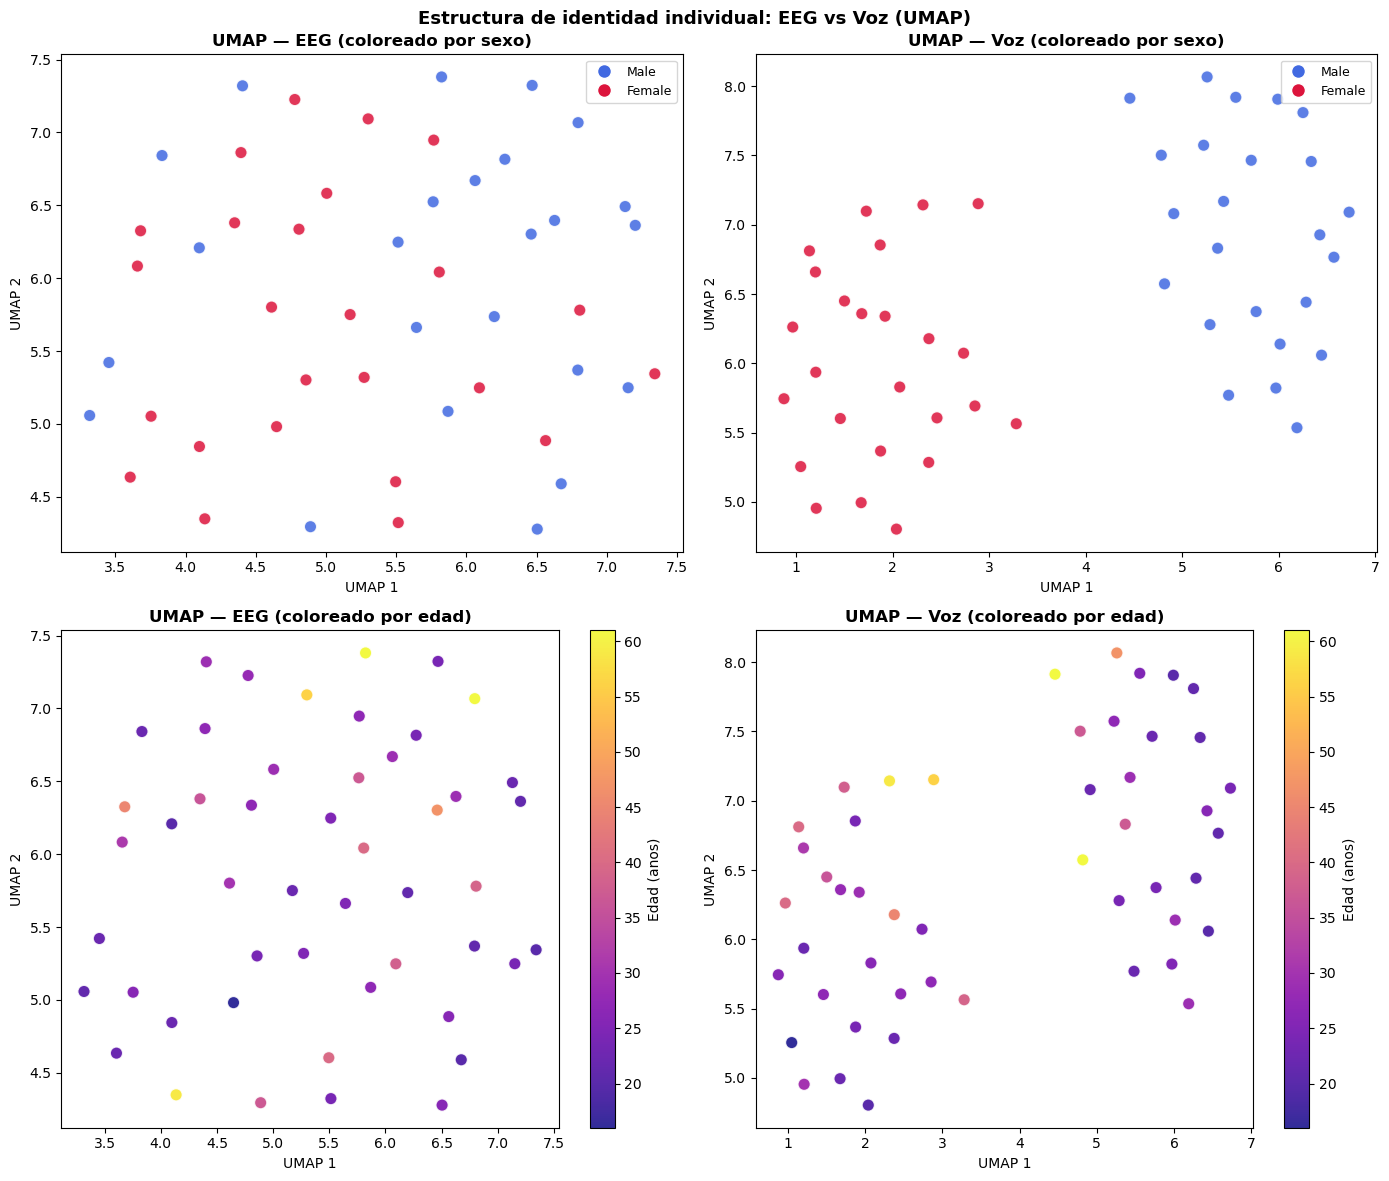

In [42]:
# ============================================================
# CELL SEX-VOICE-2: Visualizacion UMAP/PCA de EEG y Voz
# ============================================================

try:
    from umap import UMAP
    def reduce_2d(X):
        return UMAP(n_components=2, random_state=42).fit_transform(X)
    method = 'UMAP'
    print("UMAP disponible.")
except ImportError:
    from sklearn.decomposition import PCA
    def reduce_2d(X):
        return PCA(n_components=2, random_state=42).fit_transform(X)
    method = 'PCA'
    print("umap-learn no instalado, usando PCA.")
    print("Para instalar: pip install umap-learn")

y_sex_sv2 = (merged['sex'].str[0] == 'M').astype(int).values
y_age_sv2 = merged['age'].values
sex_str   = merged['sex'].str[0].values

print(f"Calculando proyecciones {method}...")
eeg_2d   = reduce_2d(X_eeg_s)
voice_2d = reduce_2d(X_voice_s)
print("  Listo.")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (X2d, label) in enumerate([(eeg_2d, 'EEG'), (voice_2d, 'Voz')]):
    # Fila 0: por sexo
    ax = axes[0, col]
    c_sex = ['royalblue' if s == 'M' else 'crimson' for s in sex_str]
    ax.scatter(X2d[:, 0], X2d[:, 1], c=c_sex, s=80,
               alpha=0.85, edgecolors='white')
    from matplotlib.lines import Line2D
    legs = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='royalblue',
               ms=10, label='Male'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',
               ms=10, label='Female'),
    ]
    ax.legend(handles=legs, fontsize=9)
    ax.set_title(f'{method} — {label} (coloreado por sexo)', fontweight='bold')
    ax.set_xlabel(f'{method} 1'); ax.set_ylabel(f'{method} 2')

    # Fila 1: por edad
    ax2 = axes[1, col]
    sc = ax2.scatter(X2d[:, 0], X2d[:, 1], c=y_age_sv2, cmap='plasma',
                     s=80, alpha=0.85, edgecolors='white')
    plt.colorbar(sc, ax=ax2, label='Edad (anos)')
    ax2.set_title(f'{method} — {label} (coloreado por edad)', fontweight='bold')
    ax2.set_xlabel(f'{method} 1'); ax2.set_ylabel(f'{method} 2')

plt.suptitle(f'Estructura de identidad individual: EEG vs Voz ({method})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## FINGER-1: Fingerprinting de identidad individual

### A) Voice fingerprinting cross-sesion (G04 -> G10)
Para cada sujeto, su embedding de voz en G04 se compara con todos los
embeddings de G10. Si el mas cercano es el mismo sujeto, es un acierto.
Mide la robustez de la firma de voz entre sesiones.

### B) EEG -> Voice retrieval (cross-modal)
Dado el EEG de un sujeto, buscamos su embedding de voz mas cercano entre
los 49 candidatos. Mide si el EEG lleva suficiente firma individual como
para identificar a alguien en el espacio de voz.

Metrica: cosine distance. Accuracy vs chance (1/n = 1/49 ~ 2%).

**Requiere:** VOICE-EEG-1 (`merged`, `X_eeg_s`, `X_voice_s`, `voice_df`, `n`)

Sujetos alineados G04 n G10 n EEG: 49
Chance level (1/n): 0.020

=== A) Voice fingerprinting cross-sesion (G04 -> G10) ===
  Top-1 accuracy: 1.000  (chance: 0.020)
  Top-5 accuracy: 1.000  (chance: 0.102)

=== B) Cross-modal EEG <-> Voz (estructura de vecindad) ===
  Nearest-neighbor match:  0.000  (chance: 0.020)
  Mean Spearman rho:       +0.023  (p_perm=0.431)
  -> EEG y Voz no comparten estructura de similitud entre sujetos.


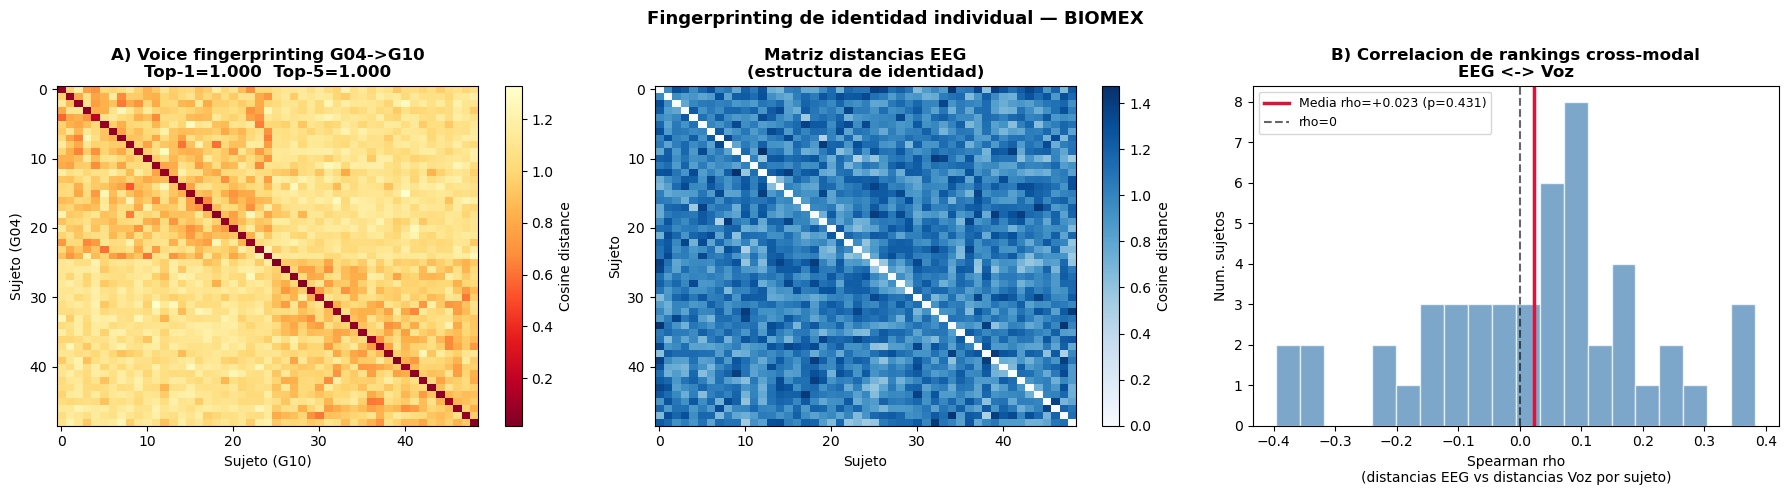

In [43]:
# ============================================================
# CELL FINGER-1: Voice fingerprinting + EEG<->Voice retrieval
#
# A) Voice fingerprinting cross-sesion (G04 -> G10):
#    Para cada sujeto en G04, busca su embedding mas cercano
#    en G10. Top-1 y Top-5 accuracy vs chance (1/49 ~ 2%).
#
# B) Cross-modal EEG <-> Voz:
#    Calcula distancias DENTRO de cada espacio por separado,
#    luego compara la estructura de vecindad.
#    - Nearest-neighbor match: mismo vecino en EEG y en Voz?
#    - Spearman rho medio: correlacion de rankings de distancia
#
# Requiere: VOICE-EEG-1 (merged, X_eeg_s, X_voice_s, voice_df, n)
# ============================================================

from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import spearmanr

voice_cols_f = [c for c in voice_df.columns if c.startswith('voice_')]
sub_ids = merged['subject_id'].values

# -- Cargar G04 y alinear sujetos -------------------------------------------
voice_g04 = pd.read_csv(
    r'C:\Users\Laura\OneDrive\Escritorio\TFM_part1\voice_embeddings_G04.csv')
g04_aligned = (voice_g04.set_index('subject_id')
                         .loc[sub_ids, voice_cols_f].values.astype(float))
g10_aligned = (voice_df.set_index('subject_id')
                        .loc[sub_ids, voice_cols_f].values.astype(float))
g04_s = StandardScaler().fit_transform(g04_aligned)
g10_s = StandardScaler().fit_transform(g10_aligned)

print(f"Sujetos alineados G04 n G10 n EEG: {n}")
print(f"Chance level (1/n): {1/n:.3f}\n")

# ============================================================
# PARTE A: Voice fingerprinting G04 -> G10
# ============================================================
dist_gg  = cosine_distances(g04_s, g10_s)         # (49, 49)
nn_gg    = np.array([np.argmin(dist_gg[i]) for i in range(n)])
acc_top1 = (nn_gg == np.arange(n)).mean()
acc_top5 = np.mean([i in np.argsort(dist_gg[i])[:5] for i in range(n)])

print("=== A) Voice fingerprinting cross-sesion (G04 -> G10) ===")
print(f"  Top-1 accuracy: {acc_top1:.3f}  (chance: {1/n:.3f})")
print(f"  Top-5 accuracy: {acc_top5:.3f}  (chance: {5/n:.3f})")

# ============================================================
# PARTE B: Cross-modal EEG <-> Voz (estructura de vecindad)
# ============================================================
# Distancias DENTRO de cada espacio (sin cross-modal directo)
dist_eeg = cosine_distances(X_eeg_s, X_eeg_s).copy()  # (49, 49)
dist_voi = cosine_distances(g10_s,   g10_s).copy()    # (49, 49)

# Excluir diagonal para nearest-neighbor
np.fill_diagonal(dist_eeg, np.inf)
np.fill_diagonal(dist_voi, np.inf)

nn_eeg        = np.argmin(dist_eeg, axis=1)
nn_voi        = np.argmin(dist_voi, axis=1)
cross_match   = (nn_eeg == nn_voi).mean()

# Correlacion de Spearman por sujeto (restaurar nan para excluir diagonal)
np.fill_diagonal(dist_eeg, np.nan)
np.fill_diagonal(dist_voi, np.nan)
rank_corrs = []
for i in range(n):
    mask = ~np.isnan(dist_eeg[i])
    rho_i, _ = spearmanr(dist_eeg[i][mask], dist_voi[i][mask])
    rank_corrs.append(rho_i)
rank_corrs = np.array(rank_corrs)
mean_rho   = np.nanmean(rank_corrs)

# Permutation test para mean_rho
rng = np.random.default_rng(42)
perm_rhos = []
for _ in range(1000):
    perm_idx  = rng.permutation(n)
    d_perm    = dist_eeg[np.ix_(perm_idx, perm_idx)]
    rho_p_list = []
    for i in range(n):
        mask = ~np.isnan(d_perm[i])
        r_p, _ = spearmanr(d_perm[i][mask], dist_voi[i][mask])
        rho_p_list.append(r_p)
    perm_rhos.append(np.nanmean(rho_p_list))
p_perm = (np.abs(np.array(perm_rhos)) >= np.abs(mean_rho)).mean()

print("\n=== B) Cross-modal EEG <-> Voz (estructura de vecindad) ===")
print(f"  Nearest-neighbor match:  {cross_match:.3f}  (chance: {1/n:.3f})")
print(f"  Mean Spearman rho:       {mean_rho:+.3f}  (p_perm={p_perm:.3f})")
if mean_rho > 0.05 and p_perm < 0.05:
    print("  -> Estructura de similitud compartida EEG <-> Voz.")
else:
    print("  -> EEG y Voz no comparten estructura de similitud entre sujetos.")

# ============================================================
# PLOTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: Matriz de distancias G04->G10 (diagonal = mismo sujeto)
ax = axes[0]
im = ax.imshow(dist_gg, cmap='YlOrRd_r', aspect='auto')
ax.set_title(f'A) Voice fingerprinting G04->G10\nTop-1={acc_top1:.3f}  Top-5={acc_top5:.3f}',
             fontweight='bold')
ax.set_xlabel('Sujeto (G10)'); ax.set_ylabel('Sujeto (G04)')
plt.colorbar(im, ax=ax, label='Cosine distance')

# B: Matrices de distancias EEG vs Voz (comparacion visual)
# Restaurar nan->0 para visualizar
dist_eeg_vis = cosine_distances(X_eeg_s, X_eeg_s)
dist_voi_vis = cosine_distances(g10_s, g10_s)

ax2 = axes[1]
im2 = ax2.imshow(dist_eeg_vis, cmap='Blues', aspect='auto')
ax2.set_title('Matriz distancias EEG\n(estructura de identidad)', fontweight='bold')
ax2.set_xlabel('Sujeto'); ax2.set_ylabel('Sujeto')
plt.colorbar(im2, ax=ax2, label='Cosine distance')

# C: Distribucion de rho por sujeto
ax3 = axes[2]
ax3.hist(rank_corrs, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
ax3.axvline(mean_rho, color='crimson', lw=2.5,
            label=f'Media rho={mean_rho:+.3f} (p={p_perm:.3f})')
ax3.axvline(0, color='k', lw=1.5, ls='--', alpha=0.6, label='rho=0')
ax3.set_xlabel('Spearman rho\n(distancias EEG vs distancias Voz por sujeto)')
ax3.set_ylabel('Num. sujetos')
ax3.set_title('B) Correlacion de rankings cross-modal\nEEG <-> Voz', fontweight='bold')
ax3.legend(fontsize=9)

plt.suptitle('Fingerprinting de identidad individual — BIOMEX',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## STAB-1: Estabilidad cross-sesión de la voz (G04 ↔ G10)

¿Qué tan estable es la firma vocal de cada sujeto entre sesiones?
- **Similitud within-subject**: coseno entre embedding G04 y G10 del mismo sujeto
- **Similitud between-subject**: coseno entre embeddings de distintos sujetos (baseline)

Si `sim_within >> sim_between`, la voz lleva una firma individual robusta en el tiempo,
lo que justifica usarla como objetivo en la Fase 3 (síntesis personalizada).

**Requiere**: FINGER-1 ejecutada (`g04_s`, `g10_s`, `n`)

=== STAB-1: Estabilidad cross-sesion de voz G04 <-> G10 ===
  Within-subject  sim (mean +/- SD): 0.926 +/- 0.027
  Between-subject sim (mean +/- SD): -0.019 +/- 0.124
  d' (discriminabilidad):            7.61
  Sujeto con menor estabilidad:      F005  sim=0.801
  Sujeto con mayor estabilidad:      M001  sim=0.983

  -> La voz es una firma individual robusta y estable entre sesiones.


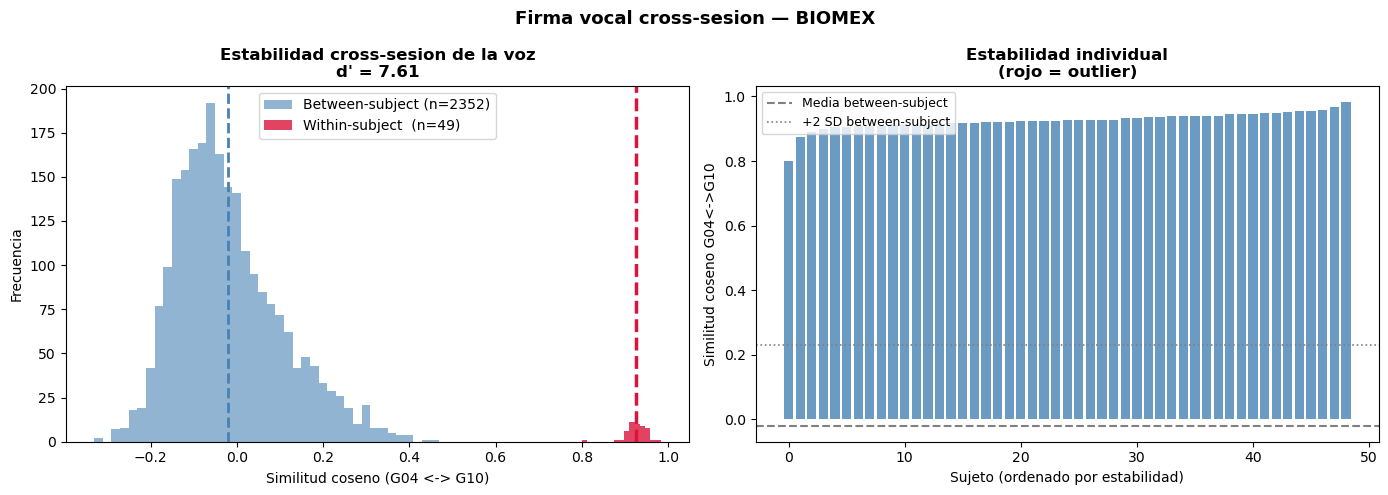

In [44]:
# ============================================================
# CELL STAB-1: Estabilidad cross-sesion de voz G04 <-> G10
#
# Requiere: FINGER-1 (g04_s, g10_s, n, sub_ids)
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Similitud coseno G04 <-> G10 para cada sujeto
sim_within = np.array([
    cosine_similarity([g04_s[i]], [g10_s[i]])[0, 0]
    for i in range(n)
])

# Similitud coseno entre distintos sujetos (off-diagonal de la matriz completa)
sim_matrix = cosine_similarity(g04_s, g10_s)           # (49, 49)
mask_off   = ~np.eye(n, dtype=bool)
sim_between = sim_matrix[mask_off]

# Discriminability d' = (mu_within - mu_between) / sigma_between
dprime = (sim_within.mean() - sim_between.mean()) / sim_between.std()

print("=== STAB-1: Estabilidad cross-sesion de voz G04 <-> G10 ===")
print(f"  Within-subject  sim (mean +/- SD): {sim_within.mean():.3f} +/- {sim_within.std():.3f}")
print(f"  Between-subject sim (mean +/- SD): {sim_between.mean():.3f} +/- {sim_between.std():.3f}")
print(f"  d' (discriminabilidad):            {dprime:.2f}")
print(f"  Sujeto con menor estabilidad:      {sub_ids[np.argmin(sim_within)]}  sim={sim_within.min():.3f}")
print(f"  Sujeto con mayor estabilidad:      {sub_ids[np.argmax(sim_within)]}  sim={sim_within.max():.3f}")

if dprime > 1.0:
    print("\n  -> La voz es una firma individual robusta y estable entre sesiones.")
else:
    print("\n  -> Estabilidad moderada; la variabilidad inter-sesion es considerable.")

# -- Plots -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: distribucion within vs between
ax = axes[0]
ax.hist(sim_between, bins=40, color='steelblue', alpha=0.6,
        label=f'Between-subject (n={len(sim_between)})')
ax.hist(sim_within,  bins=15, color='crimson',   alpha=0.8,
        label=f'Within-subject  (n={n})')
ax.axvline(sim_within.mean(),  color='crimson',   lw=2.5, ls='--')
ax.axvline(sim_between.mean(), color='steelblue', lw=2,   ls='--')
ax.set_xlabel('Similitud coseno (G04 <-> G10)')
ax.set_ylabel('Frecuencia')
ax.set_title(f"Estabilidad cross-sesion de la voz\nd' = {dprime:.2f}", fontweight='bold')
ax.legend()

# Derecha: within-subject sim por sujeto (sorted)
ax2 = axes[1]
order = np.argsort(sim_within)
colors = ['crimson' if s < sim_between.mean() + 2*sim_between.std() else 'steelblue'
          for s in sim_within[order]]
ax2.bar(range(n), sim_within[order], color=colors, alpha=0.8)
ax2.axhline(sim_between.mean(), color='gray', ls='--', lw=1.5,
            label='Media between-subject')
ax2.axhline(sim_between.mean() + 2*sim_between.std(), color='gray', ls=':', lw=1.2,
            label='+2 SD between-subject')
ax2.set_xlabel('Sujeto (ordenado por estabilidad)')
ax2.set_ylabel('Similitud coseno G04<->G10')
ax2.set_title('Estabilidad individual\n(rojo = outlier)', fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Firma vocal cross-sesion — BIOMEX', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## EEG-FING-1: EEG fingerprinting cross-condición (REC → TASK)

¿Puede identificarse a un sujeto por su EEG en una condición distinta?
- **Gallery**: features PSD de TASK (5 bandas × 14 canales = 70 features)
- **Probe**:   features PSD de REC (misma extracción)
- **Test**: para cada sujeto en REC, ¿su vecino más cercano en TASK es él mismo?

Complementa FINGER-1 (voz, Top-1=100%): si el EEG da Top-1 << 100%,
justifica la necesidad de la Fase 2 (decodificación del habla desde EEG).

**Requiere**: `find_edf`, `extract_condition_segments`, `SFREQ`, `EEG_CHANNELS` (CELL A + CELL 18)

Extrayendo features PSD por condicion (REC y TASK)...
(puede tardar ~1-2 min para 49 sujetos)

Sujetos con REC + TASK: 49  (chance = 0.020)

=== EEG fingerprinting cross-condicion (REC -> TASK) ===
  Top-1 accuracy: 0.000  (chance: 0.020,  p_perm=1.000)
  Top-5 accuracy: 0.000  (chance: 0.102)

  -> El EEG (reposo) no identifica bien al sujeto cross-condicion.
     Esto motiva Phase 2: EEG durante produccion activa de habla.


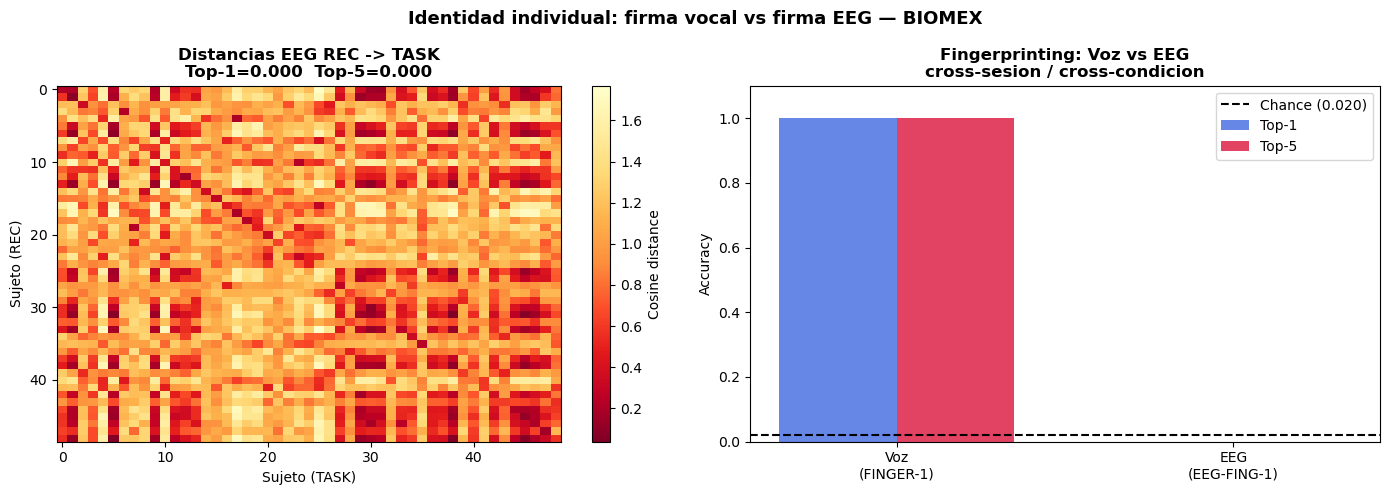

In [45]:
# ============================================================
# CELL EEG-FING-1: EEG fingerprinting cross-condicion REC->TASK
#
# Requiere: find_edf, extract_condition_segments, SFREQ,
#           EEG_CHANNELS (CELL 18 + CELL A + mini-cell SFREQ)
#           merged (VOICE-EEG-1)
# ============================================================

from scipy.signal import welch
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

BANDS_FP = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,13),
            'beta':(13,30), 'gamma':(30,45)}

def psd_features(segment, sfreq=SFREQ):
    """70-dim PSD feature vector (5 bands x 14 channels, log-power)."""
    feats = []
    for ch in range(segment.shape[0]):
        freqs, psd = welch(segment[ch], fs=sfreq,
                           nperseg=min(256, segment.shape[1]))
        for lo, hi in BANDS_FP.values():
            mask = (freqs >= lo) & (freqs < hi)
            feats.append(np.log1p(psd[mask].mean()))
    return np.array(feats)

print("Extrayendo features PSD por condicion (REC y TASK)...")
print("(puede tardar ~1-2 min para 49 sujetos)")

recs, tasks, sids_fp = [], [], []
for sid in merged['subject_id'].values:
    try:
        edf = find_edf(sid, session='G10')
        segs = extract_condition_segments(edf)
        seg_rec  = segs.get('REC')
        seg_task = segs.get('TASK')
        if seg_rec is None or seg_task is None:
            print(f"  {sid}: sin REC o TASK, skip")
            continue
        recs.append(psd_features(seg_rec))
        tasks.append(psd_features(seg_task))
        sids_fp.append(sid)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

X_rec  = StandardScaler().fit_transform(np.array(recs))   # (n_ok, 70)
X_task = StandardScaler().fit_transform(np.array(tasks))  # (n_ok, 70)
n_fp   = len(sids_fp)
print(f"\nSujetos con REC + TASK: {n_fp}  (chance = {1/n_fp:.3f})")

# Nearest-neighbor REC -> TASK
dist_rt  = cosine_distances(X_rec, X_task)          # (n_fp, n_fp)
np.fill_diagonal(dist_rt, np.inf)
nn_rt    = np.argmin(dist_rt, axis=1)
acc_top1 = (nn_rt == np.arange(n_fp)).mean()

# Top-5
np.fill_diagonal(dist_rt, np.inf)
acc_top5 = np.mean([
    i in np.argsort(dist_rt[i])[:5]
    for i in range(n_fp)
])

# Permutation test
rng = np.random.default_rng(42)
perm_acc = []
for _ in range(1000):
    perm_idx = rng.permutation(n_fp)
    perm_acc.append((perm_idx == np.arange(n_fp)).mean())
p_perm = (np.array(perm_acc) >= acc_top1).mean()

print("\n=== EEG fingerprinting cross-condicion (REC -> TASK) ===")
print(f"  Top-1 accuracy: {acc_top1:.3f}  (chance: {1/n_fp:.3f},  p_perm={p_perm:.3f})")
print(f"  Top-5 accuracy: {acc_top5:.3f}  (chance: {5/n_fp:.3f})")

if acc_top1 > 0.20:
    print("\n  -> El EEG lleva firma individual detectable cross-condicion.")
else:
    print("\n  -> El EEG (reposo) no identifica bien al sujeto cross-condicion.")
    print("     Esto motiva Phase 2: EEG durante produccion activa de habla.")

# -- Plots -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de distancias REC -> TASK
ax = axes[0]
dist_vis = cosine_distances(X_rec, X_task)
im = ax.imshow(dist_vis, cmap='YlOrRd_r', aspect='auto')
ax.set_title(f'Distancias EEG REC -> TASK\nTop-1={acc_top1:.3f}  Top-5={acc_top5:.3f}',
             fontweight='bold')
ax.set_xlabel('Sujeto (TASK)'); ax.set_ylabel('Sujeto (REC)')
plt.colorbar(im, ax=ax, label='Cosine distance')

# Comparacion EEG vs Voz fingerprinting
ax2 = axes[1]
methods = ['Voz\n(FINGER-1)', 'EEG\n(EEG-FING-1)']
top1s   = [1.000, acc_top1]
top5s   = [1.000, acc_top5]
x = np.arange(2)
w = 0.35
ax2.bar(x - w/2, top1s, w, color=['royalblue', 'steelblue'],
        alpha=0.8, label='Top-1')
ax2.bar(x + w/2, top5s, w, color=['crimson',   'salmon'],
        alpha=0.8, label='Top-5')
ax2.axhline(1/n_fp, color='k', ls='--', lw=1.5, label=f'Chance ({1/n_fp:.3f})')
ax2.set_xticks(x); ax2.set_xticklabels(methods)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Accuracy')
ax2.set_title('Fingerprinting: Voz vs EEG\ncross-sesion / cross-condicion', fontweight='bold')
ax2.legend()

plt.suptitle('Identidad individual: firma vocal vs firma EEG — BIOMEX',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()